# 5. Magnetohydrodynamics in two dimensions: keeping $\nabla\cdot\mathbf{B} = 0$

In one dimension the divergence constraint only says that $B_x$ is constant. In two dimensions it
becomes a real problem: the induction equation preserves $\nabla\cdot\mathbf{B} = 0$ exactly, but a
finite-volume scheme that treats $\mathbf{B}$ like any other conserved variable does not. Piastra's MHD
module offers three standard ways to deal with this, selected by the parameter `divb_tr`. This notebook

1. explains why divergence errors matter;
2. describes constrained transport (`'CT'`), hyperbolic divergence cleaning (`'GLM'`), and the 8-wave
   scheme (`'8wave'`);
3. compares them on the advection of a weak field loop and on the Orszag–Tang vortex;
4. ends with two astrophysical applications: the magnetorotational instability in a torus around a
   point mass, and a magnetized jet.

The complete notebook runs in several minutes.

In [1]:
import os, sys, io, contextlib
sys.path.insert(0, os.path.abspath('..'))          # the Piastra root directory

import numpy as np
import matplotlib.pyplot as plt

from src.parameters import Parameters
from src.grid.grid_setup import Grid
from src.sim_state import SimState
from src.misc.helpers import initial_model
from src.grid.grid_misc import div_face_vector, div_cell_vector
from main import SOLVER_DISPATCH


def setup(problem, N1, N2, init=None, **options):
    '''Parameters, grid, state, EOS and solver for an MHD problem of the catalogue.
    `init(grid, state, par, eos)`, if given, modifies the set-up before the solver is built.'''
    with contextlib.redirect_stdout(io.StringIO()):
        par = Parameters(mode="MHD", problem=problem, Nx1=N1, Nx2=N2, **options)
        grid = Grid(par.Nx1, par.Nx2, par.Ngc)
        state = SimState(grid, par)
        grid, state, par, eos = initial_model(grid, state, par)
        if init is not None:
            init(grid, state, par, eos)
        solver = SOLVER_DISPATCH["MHD"](grid, state, eos, par)
    return grid, state, par, eos, solver


def evolve(solver, par, t_end=None):
    '''Advance the solution to t_end (default: the final time of the problem).'''
    if t_end is not None:
        par.timefin = t_end
    with contextlib.redirect_stdout(io.StringIO()):
        while par.timenow < par.timefin - 1e-12:
            state = solver.step_RK()
    return state


def interior(grid, array):
    '''Interior (non-ghost) cells of a 2D array.'''
    g = grid.Ngc
    return array[g:-g, g:-g].copy()


def magnetic_energy(grid, state):
    B2 = sum(interior(grid, b)**2 for b in (state.bfi1, state.bfi2, state.bfi3))
    return 0.5 * np.sum(grid.cVol * B2)


def total_energy(grid, state, eos):
    '''Total energy (kinetic + thermal + magnetic) from the primitive variables.'''
    rho, p = interior(grid, state.dens), interior(grid, state.pres)
    v2 = sum(interior(grid, v)**2 for v in (state.vel1, state.vel2, state.vel3))
    B2 = sum(interior(grid, b)**2 for b in (state.bfi1, state.bfi2, state.bfi3))
    return np.sum(grid.cVol * (0.5 * rho * v2 + p / (eos.GAMMA - 1.0) + 0.5 * B2))


def div_B(grid, state, par):
    '''max |div B| dx / max |B| for two definitions of the divergence:
    through the faces of the staggered field (the quantity CT controls; only CT evolves
    the face fields) and by central differences of the cell-centred field.'''
    Bmax = np.sqrt(np.max(sum(interior(grid, b)**2 for b in (state.bfi1, state.bfi2))))
    dx = np.min(grid.dx1)
    cell = np.max(np.abs(div_cell_vector(grid, state.bfi1, state.bfi2))) * dx / Bmax
    if par.divb_tr != 'CT':
        return float('nan'), cell
    face = np.max(np.abs(div_face_vector(grid, state.fb1, state.fb2))) * dx / Bmax
    return face, cell

## 1. Why the divergence matters

Taking the divergence of the induction equation gives $\partial_t(\nabla\cdot\mathbf{B}) = 0$: a field
that starts solenoidal stays solenoidal. A discretization does not inherit this property automatically.
If $\mathbf{B}$ is stored at cell centres and updated with face fluxes like the other variables, no
discrete divergence is conserved, and errors appear wherever the field has structure.

Such errors are not harmless. The conservative momentum flux $-\mathbf{B}\mathbf{B}$ produces the
Lorentz force only if $\nabla\cdot\mathbf{B} = 0$; otherwise it contains an extra force
$-\mathbf{B}\,(\nabla\cdot\mathbf{B})$ **parallel** to the field (similar to the electromotive 
force $\sim\mathbf{E}\nabla\cdot\mathbf{E}$), which a real magnetic field can never
exert (Brackbill & Barnes 1980). In practice this means spurious acceleration along field lines,
wrong jump conditions at shocks, and sometimes negative pressures and a crashed run.

## 2. Three strategies

**Constrained transport (CT; Evans & Hawley 1988).** The normal components of $\mathbf{B}$ are stored
on the cell faces and updated with Faraday's law in integral form: the change of the magnetic flux
through a face equals the circulation of the electric field $\mathbf{E} = -\mathbf{v}\times\mathbf{B}$
around its edges,
$$\frac{d}{dt}\left(B_x\,\Delta y\right)_{i+1/2,j} = -\left(E_{z,\,i+1/2,j+1/2} - E_{z,\,i+1/2,j-1/2}\right),$$
and similarly for $B_y$. Every edge electric field enters the fluxes of the faces that share it with
opposite signs, so the sum of the fluxes out of a cell — the discrete divergence — does not change at
all. If the initial field is computed from a vector potential at the cell corners, the divergence is
zero to round-off forever. Piastra obtains the corner electric field as the arithmetic average of the
four neighbouring face values from the Riemann solvers (Balsara & Spicer 1999).

**Hyperbolic–parabolic cleaning (GLM; Dedner et al. 2002).** All fields stay at cell centres, and a new
scalar $\psi$ is coupled to the induction equation,
$$\partial_t\mathbf{B} + \nabla\cdot(\mathbf{v}\mathbf{B} - \mathbf{B}\mathbf{v}) + \nabla\psi = 0,
\qquad \partial_t\psi + c_h^2\,\nabla\cdot\mathbf{B} = -\frac{c_h^2}{c_p^2}\,\psi .$$
Divergence errors then obey a damped wave equation: they propagate away at the speed $c_h$ and decay.
Piastra uses the largest fast magnetosonic speed for $c_h$ and damps $\psi$ at the rate
$0.1\,c_h/\Delta x$.

**The 8-wave scheme (Powell 1994; Powell et al. 1999).** Source terms proportional to
$\nabla\cdot\mathbf{B}$ are added to the equations, $-(\nabla\cdot\mathbf{B})\,(0, \mathbf{B}, \mathbf{v},
\mathbf{v}\cdot\mathbf{B})$ for (mass, momentum, induction, energy). They cancel the unphysical force and
make the divergence a passive quantity advected with the flow. The price is that the equations are no
longer in conservation form: momentum and energy are not conserved exactly.

Note that "the divergence" is not a single number: CT keeps the divergence *through the faces* at
round-off, but the central-difference divergence of the cell-centred field (obtained from the faces by
interpolation) is not zero. The function `div_B` above reports both.

## 3. Test 1: advection of a weak field loop

A cylinder of weak magnetic field — field lines forming circles, $\beta \sim 10^6$ — is advected
diagonally across a periodic domain for one period (Gardiner & Stone 2005). The field is dynamically
irrelevant, so the loop should simply move; the test isolates how well the induction equation is
solved. The discontinuities of the field at the centre and at the rim of the loop make it a hard test.

divb_tr  E_mag(t=1)/E_mag(0)  div through faces  div at centres
CT                     0.880            4.2e-15         4.9e-03
GLM                    0.826                nan         3.3e-03
8wave                  0.852                nan         1.6e-01


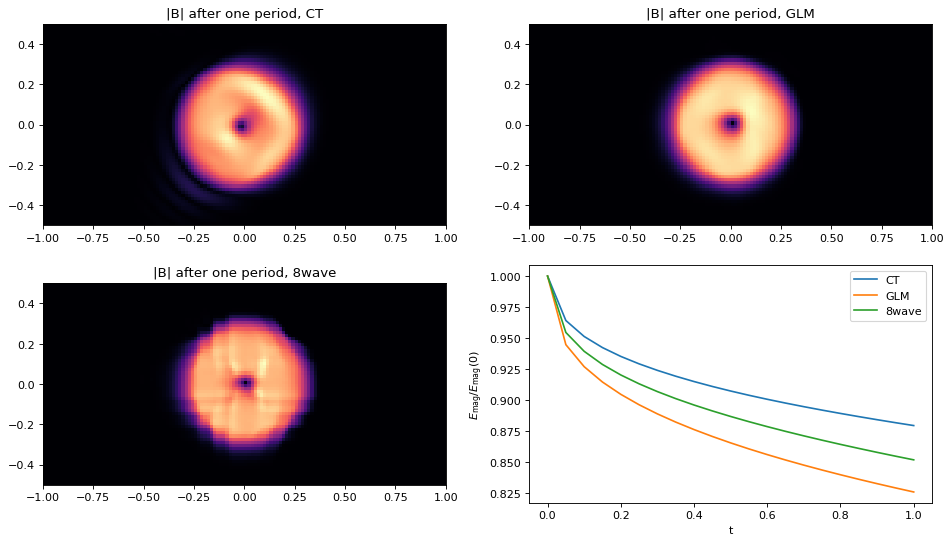

In [2]:
strategies = ['CT', 'GLM', '8wave']
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
print(f"{'divb_tr':7s} {'E_mag(t=1)/E_mag(0)':>20s} {'div through faces':>18s} {'div at centres':>15s}")
for ax, dv in zip(axes.ravel(), strategies):
    grid, state, par, eos, solver = setup("field-loop", 128, 64, divb_tr=dv, rec_type='PLM',
                                           RK_order='RK2', solver_type='HLLD', CFL=0.5)
    times, emag = [0.0], [magnetic_energy(grid, state)]
    for t in np.linspace(0.05, 1.0, 20):
        state = evolve(solver, par, t_end=t)
        times.append(par.timenow); emag.append(magnetic_energy(grid, state))
    face, cell = div_B(grid, state, par)
    print(f"{dv:7s} {emag[-1] / emag[0]:20.3f} {face:18.1e} {cell:15.1e}")
    B = np.sqrt(interior(grid, state.bfi1)**2 + interior(grid, state.bfi2)**2)
    ax.pcolormesh(interior(grid, grid.cx1), interior(grid, grid.cx2), B, shading='auto', cmap='magma')
    ax.set_aspect('equal'); ax.set_title(f'|B| after one period, {dv}')
    axes[1, 1].plot(times, np.array(emag) / emag[0], label=dv)
axes[1, 1].set_xlabel('t'); axes[1, 1].set_ylabel(r'$E_{\rm mag}/E_{\rm mag}(0)$'); axes[1, 1].legend()
plt.tight_layout(); plt.show()

The three runs differ more than their magnetic energies (a loss of 12–17 per cent) suggest.

* **CT** keeps the divergence through the faces at round-off, and it loses the least energy. But the
  loop is surrounded by a ripple trailing behind it, and its interior is slightly asymmetric. This is
  the known weakness of the *arithmetic* average of the edge electric fields used by Piastra: the
  average carries no upwind dissipation, and the test exposes it (Gardiner & Stone 2005, who introduced
  upwinded edge fields for exactly this reason — see the exercises).
* **GLM** gives the smoothest, most symmetric loop, and it is also the most diffusive one. Measured at
  cell centres, its divergence errors are as small as those of CT.
* The **8-wave** scheme distorts the loop into a grid-aligned cross, and its divergence errors, which it
  only advects, are thirty to fifty times larger.

The central-difference divergence of the CT field is not zero: CT controls the divergence that it
defines, the one through the cell faces, and no other.

## 4. Test 2: the Orszag–Tang vortex

The Orszag–Tang vortex starts from smooth, periodic velocity and magnetic fields and quickly develops
interacting shocks and current sheets: it is the standard test of how a scheme copes with MHD shocks in
two dimensions. Since the domain is periodic, the total energy must be conserved; since shocks form,
the jump conditions matter.

divb_tr  dE_tot/E_tot  div through faces  div at centres
CT            7.3e-15            6.3e-15         4.9e-02
GLM           7.3e-15                nan         4.5e-02
8wave         9.7e-04                nan         1.5e-01


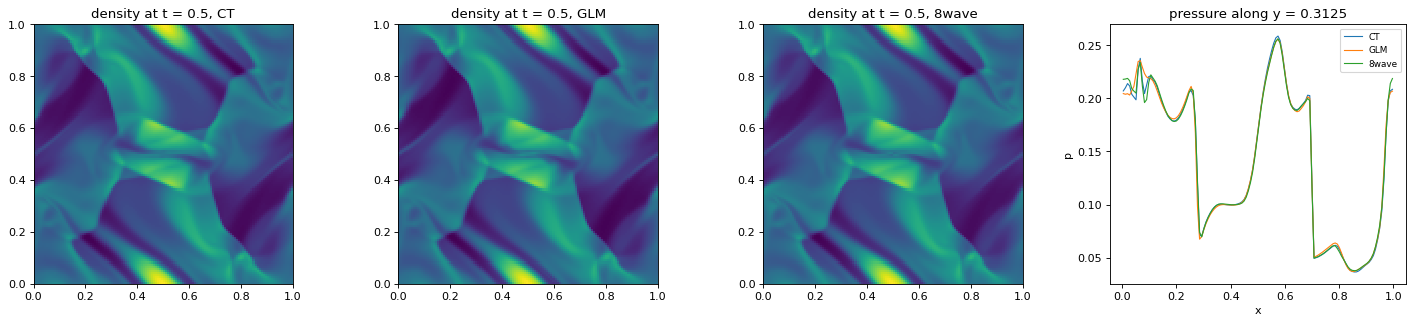

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
print(f"{'divb_tr':7s} {'dE_tot/E_tot':>13s} {'div through faces':>18s} {'div at centres':>15s}")
for ax, dv in zip(axes, strategies):
    grid, state, par, eos, solver = setup("OT2D", 128, 128, divb_tr=dv, rec_type='PLM',
                                           RK_order='RK2', solver_type='HLLD', CFL=0.5)
    E0 = total_energy(grid, state, eos)
    state = evolve(solver, par, t_end=0.5)
    face, cell = div_B(grid, state, par)
    print(f"{dv:7s} {total_energy(grid, state, eos) / E0 - 1.0:13.1e} {face:18.1e} {cell:15.1e}")
    rho = interior(grid, state.dens)
    ax.pcolormesh(interior(grid, grid.cx1), interior(grid, grid.cx2), rho, shading='auto', cmap='viridis')
    ax.set_aspect('equal'); ax.set_title(f'density at t = 0.5, {dv}')
    j = int(0.3125 * grid.Nx2)                             # the classic cut y = 0.3125
    axes[3].plot(interior(grid, grid.cx1)[:, j], interior(grid, state.pres)[:, j], lw=1, label=dv)
axes[3].set_xlabel('x'); axes[3].set_ylabel('p'); axes[3].set_title('pressure along y = 0.3125'); axes[3].legend(fontsize=8)
plt.tight_layout(); plt.show()

The three density maps are very similar: at this resolution the Orszag–Tang vortex is forgiving, and
all strategies reproduce its well-known pattern. The diagnostics, not the pictures, tell them apart.
CT and GLM conserve the total energy to round-off; the non-conservative source terms of the 8-wave scheme
change it by about $10^{-3}$ of its value. Only CT keeps a discrete divergence at round-off, but at cell
centres its errors are of the same size as those of GLM, and those of the 8-wave scheme are three times
larger. The differences grow in problems with strong shocks, where the 8-wave scheme can produce wrong
jump conditions (Tóth 2000).

In summary:

| | CT | GLM | 8-wave |
|---|---|---|---|
| where $\mathbf{B}$ lives | faces (+ interpolated centres) | centres | centres |
| discrete $\nabla\cdot\mathbf{B}$ | zero to round-off (faces) | small, propagated and damped | small, advected |
| conservation | exact | exact | not exact |
| initial and boundary data | need a vector potential / consistent face fields | anything | anything |
| complexity | highest | moderate | lowest |

The last rows explain why cleaning methods are popular despite the elegance of CT: any field — from an
analytic formula, from a boundary inflow, from another code — can be used as it is.

## 5. Application 1: the magnetorotational instability in a torus

A torus of gas with constant specific angular momentum, in equilibrium in the potential of a point
mass (`disk2D`, axisymmetric $(R, z)$ grid), is threaded by a weak poloidal field whose field lines
follow the density contours ($\beta \ge 100$). Two processes follow.

* **Winding.** The rotation of the torus is differential, $\Omega \propto R^{-2}$, so the radial
  field is sheared into a toroidal one: $B_\varphi$ grows linearly in time and the toroidal magnetic
  energy as $t^2$.
* **The magnetorotational instability** (MRI; Balbus & Hawley 1991). A weak field in a disk whose
  angular velocity decreases outward is unstable: field lines act like springs connecting fluid elements
  at different radii and transfer angular momentum outward. The poloidal field grows exponentially,
  with a maximal rate $q\Omega/2$, where $q = -d\ln\Omega/d\ln R$; for this torus $q = 2$ and the rate
  equals $\Omega$. In axisymmetry the MRI forms radial "channel" flows; turbulence and a sustained
  dynamo need three dimensions (Cowling's theorem).

The initial field is computed by numerical differentiation of a vector potential at cell centres and
is not solenoidal in the CT sense, so the problem uses GLM. We follow the poloidal and toroidal
magnetic energies over five orbits at the pressure maximum (the orbital period there is $2\pi$):

growth rate of the poloidal field (half the energy rate): 0.072 Omega (linear theory: up to 1 Omega)


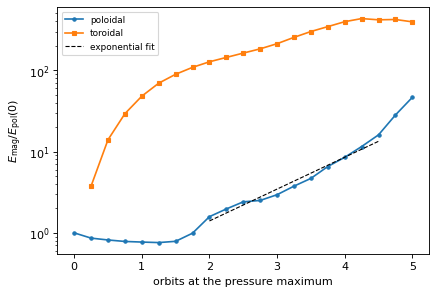

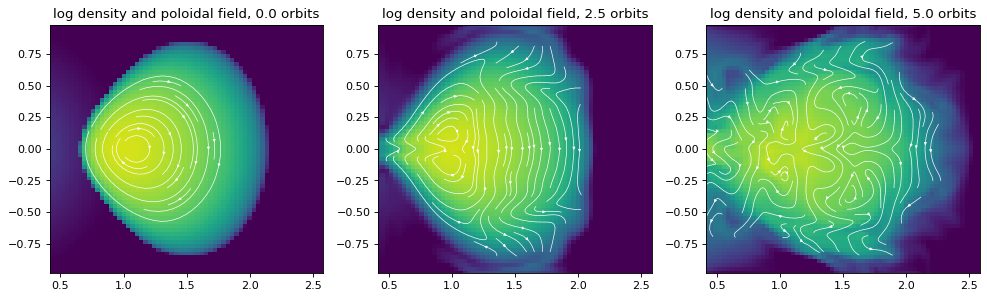

In [4]:
grid, state, par, eos, solver = setup("disk2D", 64, 64, divb_tr='GLM', rec_type='PLM', RK_order='RK2',
                                       solver_type='HLLD', CFL=0.5)
T_orb = 2.0 * np.pi
R, z = interior(grid, grid.cx1), interior(grid, grid.cx2)

def energies(state):
    V = grid.cVol
    pol = 0.5 * np.sum(V * (interior(grid, state.bfi1)**2 + interior(grid, state.bfi2)**2))
    tor = 0.5 * np.sum(V * interior(grid, state.bfi3)**2)
    return pol, tor

orbits, E_pol, E_tor, snapshots = [0.0], [], [], {}
p0, t0 = energies(state); E_pol.append(p0); E_tor.append(t0)
snapshots[0.0] = (interior(grid, state.dens), interior(grid, state.bfi1), interior(grid, state.bfi2))
for k in range(1, 21):
    state = evolve(solver, par, t_end=k * T_orb / 4)
    orbits.append(k / 4)
    p, t = energies(state); E_pol.append(p); E_tor.append(t)
    if k in (10, 20):
        snapshots[k / 4] = (interior(grid, state.dens), interior(grid, state.bfi1), interior(grid, state.bfi2))

orbits, E_pol, E_tor = np.array(orbits), np.array(E_pol), np.array(E_tor)
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(orbits, E_pol / E_pol[0], 'o-', ms=3, label='poloidal')
ax.semilogy(orbits[1:], E_tor[1:] / E_pol[0], 's-', ms=3, label='toroidal')
fit = (orbits >= 2.0) & (orbits <= 4.5)
slope = np.polyfit(orbits[fit] * T_orb, np.log(E_pol[fit]), 1)[0]
ax.semilogy(orbits[fit], np.exp(np.polyval(np.polyfit(orbits[fit], np.log(E_pol[fit] / E_pol[0]), 1), orbits[fit])),
            'k--', lw=1, label='exponential fit')
ax.set_xlabel('orbits at the pressure maximum'); ax.set_ylabel(r'$E_{\rm mag} / E_{\rm pol}(0)$'); ax.legend(fontsize=8)
plt.show()
print(f"growth rate of the poloidal field (half the energy rate): {0.5 * slope:.3f} Omega "
      f"(linear theory: up to 1 Omega)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (orb, (rho, BR, Bz)) in zip(axes, snapshots.items()):
    ax.pcolormesh(R, z, np.log10(rho), shading='auto', cmap='viridis', vmin=-3, vmax=0.2)
    torus = rho > 0.01                                  # draw field lines inside the torus only
    ax.streamplot(R[:, 0], z[0, :], np.where(torus, BR, np.nan).T, np.where(torus, Bz, np.nan).T,
                  color='w', density=1.2, linewidth=0.6, arrowsize=0.5)
    ax.set_xlim(R.min(), R.max()); ax.set_ylim(z.min(), z.max())
    ax.set_aspect('equal'); ax.set_title(f'log density and poloidal field, {orb:.1f} orbits')
plt.show()

The toroidal energy grows first — winding needs no instability — and within four orbits it exceeds
the initial poloidal energy by a factor of several hundred; its pressure becomes comparable to the gas
pressure, and the torus swells. The poloidal energy stays roughly constant for about one and a half
orbits and then grows exponentially: this is the MRI, and the field lines inside the torus lose their
initial nested shape.

The measured growth rate, however, is more than ten times lower than the linear maximum $\Omega$. The
fastest MRI mode has the wavelength $\lambda \approx 2\pi v_A/\Omega$, which for this weak field is
resolved by only about six cells on a $64^2$ grid, and numerical dissipation suppresses it. MRI
simulations need at least 10–20 cells per $\lambda$; at the resolution of a classroom run the MRI is
present, but its growth rate is set by the grid, not by the physics (see the exercises).

## 6. Application 2: a magnetized jet

A supersonic jet (Mach 6, ten times lighter than its surroundings) is injected through a nozzle at the
bottom of an axisymmetric $(R, z)$ domain (`jet2Dcyl`). The whole domain is threaded by a uniform axial
field. Hydrodynamic jets are surrounded by a broad cocoon of shocked jet material, whose boundary is
Kelvin–Helmholtz unstable; an axial magnetic field resists the bending of field lines, stabilizes this
boundary, and keeps the cocoon narrower. We compare the catalogue set-up, $\beta = 100$ (a nearly
hydrodynamic jet), with a strongly magnetized one, $\beta = 1$, obtained by rescaling the field in the
whole domain and in the nozzle; the gas pressure need not change, since a uniform field exerts no
force. As for the torus, the inflow boundary sets cell-centred values, so the runs use GLM.

beta =   100: bow shock on the axis at z = 16.2
beta =     1: bow shock on the axis at z = 13.7
hydrodynamic estimate v_h t = v_jet t / (1 + eta^-1/2) = 14.4


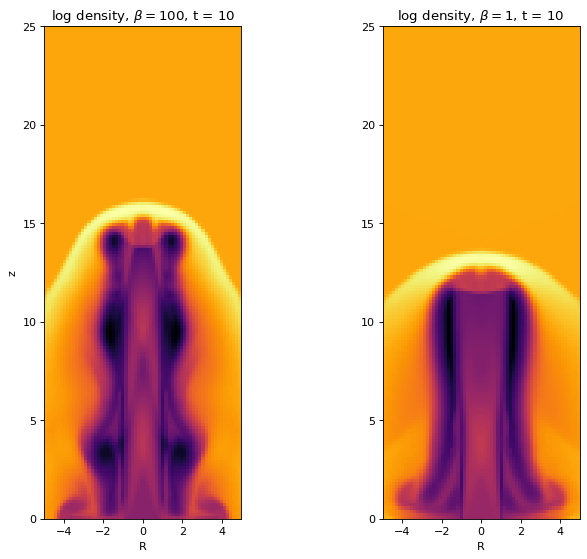

In [5]:
def axial_field(beta):
    def init(grid, state, par, eos):
        B0 = np.sqrt(2.0 * 0.6 / beta)                    # p_jet = 0.6 in the catalogue set-up
        state.bfi2[:, :] = B0
        state.fb2[:, :] = B0
        par.BC_fixed[1][0][2]['bfi2'] = B0                # the field entering through the nozzle
    return init

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
for ax, beta in zip(axes, [100.0, 1.0]):
    grid, state, par, eos, solver = setup("jet2Dcyl", 32, 160, init=axial_field(beta), divb_tr='GLM',
                                           rec_type='PLM', RK_order='RK2', solver_type='HLLD', CFL=0.5)
    state = evolve(solver, par, t_end=10.0)
    R, z, rho = interior(grid, grid.cx1), interior(grid, grid.cx2), interior(grid, state.dens)
    # mirror the axisymmetric solution to show the full jet
    Rm = np.concatenate([-R[::-1], R]); zm = np.concatenate([z[::-1], z]); rhom = np.concatenate([rho[::-1], rho])
    ax.pcolormesh(Rm, zm, np.log10(rhom), shading='auto', cmap='inferno')
    ax.set_aspect('equal'); ax.set_xlabel('R'); ax.set_title(rf'log density, $\beta = {beta:g}$, t = 10')
    on_axis = rho[0, :]                                 # the bow shock compresses the ambient gas
    head = z[0, np.abs(on_axis / on_axis[-1] - 1.0) > 0.05].max()
    print(f"beta = {beta:5g}: bow shock on the axis at z = {head:.1f}")
axes[0].set_ylabel('z')
eta = 0.1
print(f"hydrodynamic estimate v_h t = v_jet t / (1 + eta^-1/2) = {6.0 * 10.0 / (1.0 + eta**-0.5):.1f}")
plt.show()

The weakly magnetized jet looks like its hydrodynamic counterpart: its head advances roughly at the
rate predicted by the balance of ram pressures, $v_h \approx v_j/(1 + \eta^{-1/2})$, and it is
surrounded by a cocoon in which Kelvin–Helmholtz vortices form. The strongly magnetized jet is
different in two ways. Its cocoon is laminar: the tension of the axial field suppresses the vortices,
and the cocoon is bounded by straight, field-aligned walls. And its head is slower and blunt. At the
working surface the jet material must turn sideways, dragging its own field lines with it; the
tension of the bent field lines resists this, the head widens, and the thrust of the jet is spread over
a larger area. (In the $\beta = 1$ run a weak pressure disturbance also runs far ahead of the bow shock
along the axis; it is barely visible in the density, which is why the bow shock is located here by the
density jump. Finding its origin is a good exercise.)

## Summary

* Finite-volume schemes do not conserve $\nabla\cdot\mathbf{B}$ by themselves; the resulting errors
  produce unphysical forces along the field.
* CT keeps a discrete divergence at round-off by construction but needs face-centred data; GLM
  propagates and damps the errors and works with any data; the 8-wave scheme advects them and gives up
  exact conservation.
* On standard tests the three give similar pictures; conservation and divergence diagnostics tell them
  apart.
* Astrophysical MHD problems need resolution arguments of their own: the MRI is present on a coarse grid
  but its growth rate is set by numerical dissipation.

## Exercises

1. Replace the arithmetic average of the edge electric fields in `MHD_step_CT.py` by the upwind
   reconstruction of Gardiner & Stone (2005) and repeat the field-loop test.
2. Run the magnetized blast wave (`blast2Dcart`) with the three strategies and compare the total energy
   and the positions of the shocks.
3. Change the damping rate of the GLM scalar (the factor 0.1 in `MHD_step_GLM.py`). What happens to the
   divergence errors in the field-loop test for rates much smaller and much larger than $c_h/\Delta x$?
4. Run the torus at $128^2$. How does the measured MRI growth rate change? Estimate how many cells per
   fastest-growing wavelength you need to get within 20 per cent of $\Omega$.
5. Build the initial field of the torus for CT: compute the vector potential $A_\varphi$ at the cell
   corners and use `edge_to_face_curl` (as in the `field-loop` set-up) to obtain the face fields.
6. Add a toroidal field to the jet (the parameter `Bphi0` in `IC_MHD2D_jet_cyl`). What does the hoop
   stress do to the jet?